### This notebook compute "VSB1. Water Volume granted for agricultural purposes" indicator for the 27 basins of IKI Project

Spanish: Índice del volumen de agua otorgado para fines agrarios

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  

**Project #:** 0219481  

**Last modified:** 1/7/2026 by Sophia (sbakar@rti.org)

**Status:** Completed and loaded in SQLite database for the baseline and first future scenario. 

**QA Status:** reviewed by  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad
 
**Packages:** pandas, numpy, geopandas, sqlite3, matplotlib  

**Inputs:**   Shapefile of COMIDs and associated area and districts, RTI_Generated csv of DUA_agricola based on SNIRH and ALA information. 

**Outputs:** 
 
**Assumptions:** 

**N/A Handing:** Replace zeros and Inf/-Inf with NaN.  
 
**Future work:** 
 
**Notes:** Large variation between COMIDs that have water rights for agricultural purposes, so plots (for QC purposes) are scaled between the 5th and 95th percentile for visualization purposes only. Values imported to the database are the raw values.   

General Methodology:  
1. Join DUA data frame with COMID shapefile.  
2. Normaize volumes by COMID area (sq km).  

In [ ]:
## Steps for QC
# Verify that the first code cells follow this structure
# 1) import libraries
# 2) set up user and database path (this will eventually change based on how we set up the repo/distribute the input data)
# 3) set up indicator ID and get scenarios from the database - for now we are just populating the database for scenarios 1 and 2, but there should be commented lines to get all available scenarios from the database
# 4) define filepaths for input data (again this will eventually change so for now we want all the filepaths in one block to change later)

# Then verify that the rest of the code performs the intended calculations and outputs the expected results. You can run up until the sql insert which is the last three cells in the notebook.
# Make sure the code to perform the calculations is well-organized and commented for clarity.
# Add notes about the methodology, assumptions, and anything that sticks out about the results in the markdown block at the top of the page.
# Add any notes about NaN/0 handling in the markdown block under notes or assumptions
# Add a section in the markdown "QA performed by:" so that we know who checked and when 


In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
# set up user and database path
#user = 'jmayo'
#user= 'cpickering'
#user = 'sgilson'
#user = 'nreynolds'
user = 'sbakar'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"


In [3]:
# set up indicator ID and get scenarios from database
IndID= 301 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [8]:
# define filepaths for input data
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

#read in agricultural demand csv that is associated by COMID 
# DUA_agricola_csv = fr'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/Demandas/DUA_23082024_agricola_Shapefile.csv'
DUA_agricola_csv = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\Demandas\DUA_23082024_agricola_Shapefile.csv"

In [9]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
DUA_agricola_df = pd.read_csv(DUA_agricola_csv, encoding='latin1')

C:\Users\sbakar\AppData\Local\Temp\ipykernel_77832\2056820112.py:3: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  DUA_agricola_df = pd.read_csv(DUA_agricola_csv, encoding='latin1')


DUA_agricola_df shape before grouping: (3274, 2)
Unique COMIDs in CSV: 3274
DUA_agricola_df shape after grouping: (3274, 2)
Final GDF shape: (3655, 11)
Unique COMIDs in final GDF: 3655
Number of NaN values: 1895


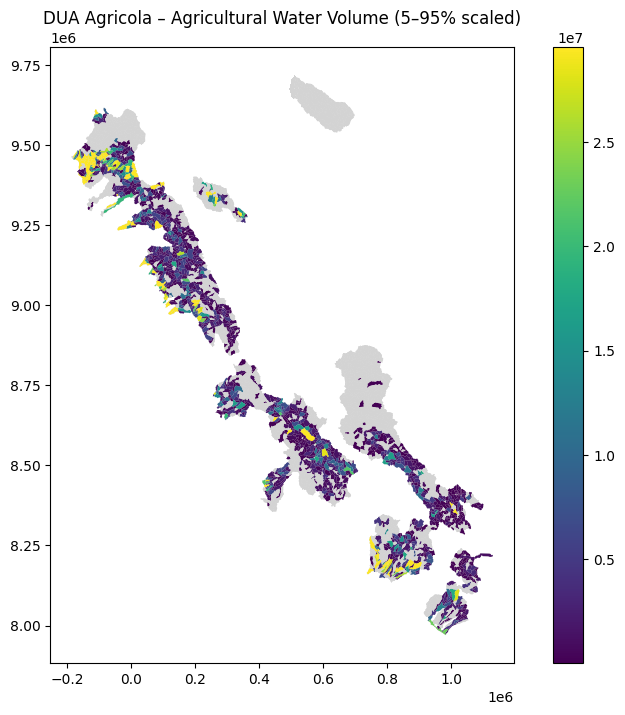

In [11]:
#join DUA_agricola to subbasins_gdf by COMID
# Check for duplicate COMIDs in the CSV and sum them first if needed
print("DUA_agricola_df shape before grouping:", DUA_agricola_df.shape)
print("Unique COMIDs in CSV:", DUA_agricola_df['COMID'].nunique())

# Group by COMID and sum Vol_der
DUA_agricola_df = DUA_agricola_df.groupby('COMID', as_index=False)['Vol_der'].sum()
print("DUA_agricola_df shape after grouping:", DUA_agricola_df.shape)

# Merge to subbasins
DUA_agricola_gdf = subbasins_gdf.merge(
    DUA_agricola_df[['COMID', 'Vol_der']],
    on='COMID',
    how='left'
)

# Convert 0s to NaN 
DUA_agricola_gdf['Vol_der'] = DUA_agricola_gdf['Vol_der'].replace(0, np.nan)

print("Final GDF shape:", DUA_agricola_gdf.shape)
print("Unique COMIDs in final GDF:", DUA_agricola_gdf['COMID'].nunique())
print("Number of NaN values:", DUA_agricola_gdf['Vol_der'].isna().sum())

# %%
# Improve plot color scaling
# Use only non-NaN values and clip color scale to 5–95th percentile

vmin = DUA_agricola_gdf['Vol_der'].quantile(0.05)
vmax = DUA_agricola_gdf['Vol_der'].quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot background (no data)
subbasins_gdf.plot(
    ax=ax,
    color='lightgrey',
    edgecolor='none'
)

# Plot agricultural demand
DUA_agricola_gdf.plot(
    column='Vol_der',
    ax=ax,
    legend=True,
    cmap='viridis',
    vmin=vmin,
    vmax=vmax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No agricultural demand"
    }
)

plt.title('DUA Agricola – Agricultural Water Volume (5–95% scaled)')
plt.show()

In [13]:
#Calculate Index
#Normalize by area of COMID 
DUA_agricola_gdf['Vol_der_norm'] = DUA_agricola_gdf['Vol_der'] / DUA_agricola_gdf['AREASQKM'] 

# Handle division by zero or very small areas
DUA_agricola_gdf['Vol_der_norm'] = DUA_agricola_gdf['Vol_der_norm'].replace([np.inf, -np.inf], np.nan)

# set any 0s to NaN
DUA_agricola_gdf['Vol_der_norm'] = DUA_agricola_gdf['Vol_der_norm'].replace(0, np.nan)

#Round to 2 decimals
DUA_agricola_gdf['Vol_der_norm'] = DUA_agricola_gdf['Vol_der_norm'].round(2)

print("Number of NaN values:", DUA_agricola_gdf['Vol_der_norm'].isna().sum())

Number of NaN values: 1895


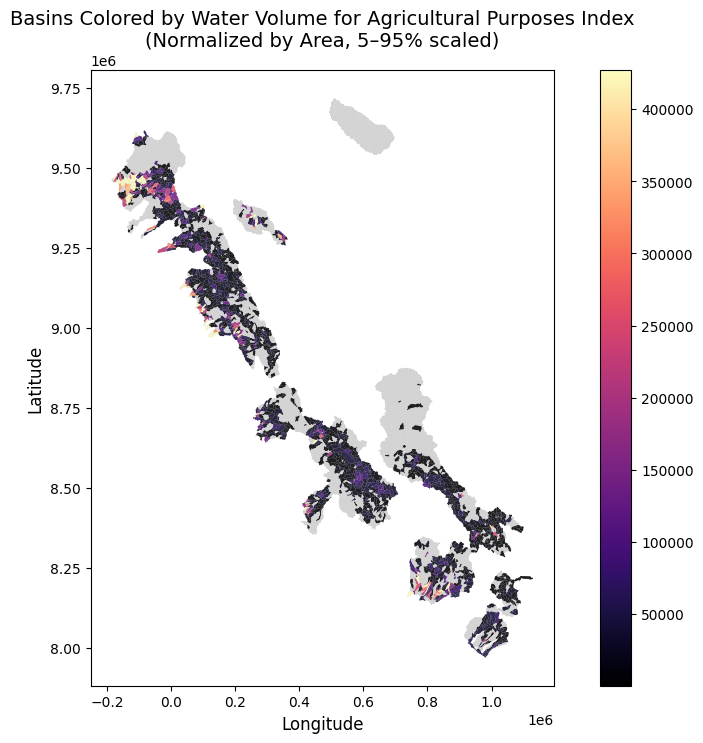

In [14]:
# Plot the basins colored by the feature count
vmin = DUA_agricola_gdf['Vol_der_norm'].quantile(0.05)
vmax = DUA_agricola_gdf['Vol_der_norm'].quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 8))

# Plot background (no data)
DUA_agricola_gdf.plot(
    ax=ax,
    color='lightgrey',
    edgecolor='none'
)

# Plot normalized values
DUA_agricola_gdf.plot(
    ax=ax,
    column='Vol_der_norm',
    legend=True,
    cmap='magma',
    vmin=vmin,
    vmax=vmax,
    alpha=0.85,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

plt.title(
    'Basins Colored by Water Volume for Agricultural Purposes Index\n'
    '(Normalized by Area, 5–95% scaled)',
    fontsize=14
)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

plt.show()

In [15]:
# insert results into the database 
insert_data= DUA_agricola_gdf #COMID 
value_column= 'Vol_der_norm' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [16]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    DUA_agricola_gdf['Vol_der_norm']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 301  Min: 0, Max: 1

=== Values to be inserted (by scenario) ===
   index  Vol_der_norm
0    min          0.07
1    max   15489408.54
2  count       1760.00
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [17]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()